In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/heribertovs/Library/CloudStorage/OneDrive-ITESO/Semestre 6/Programacion para Mineria De Datos/Proyecto/Proyecto-PMD_Calidad_Aire/data/processed/ds_final.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,datetime,estacion,O3,PM10,PM2.5
0,2020-01-01 00:00:00,Centro,0.010,48.0,32.0
1,2020-01-01 01:00:00,Centro,0.002,92.0,73.0
2,2020-01-01 08:00:00,Centro,0.008,23.0,10.0
3,2020-01-01 13:00:00,Centro,0.018,37.0,5.0
4,2020-01-01 14:00:00,Centro,0.017,127.0,6.0


In [4]:
df.info()
df["estacion"].unique()

<class 'pandas.DataFrame'>
RangeIndex: 98503 entries, 0 to 98502
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  98503 non-null  datetime64[us]
 1   estacion  98503 non-null  str           
 2   O3        98503 non-null  float64       
 3   PM10      98503 non-null  float64       
 4   PM2.5     98503 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 3.8 MB


<StringArray>
['Centro', 'Miravalle', 'Las Pintas', 'Vallarta', 'Aguilas', 'Tlaquepaque']
Length: 6, dtype: str

	1.	¿Cómo varían los niveles de O3, PM10 y PM2.5 a lo largo del día?

## Pregunta 1
¿Cómo han variado los niveles de O3, PM10 y PM2.5 a lo largo del tiempo (2020–2024) considerando el comportamiento mensual?

In [11]:
df["anio"] = df["datetime"].dt.year
df["mes"] = df["datetime"].dt.month

df_mes_std = df.groupby(["anio", "mes"])[["PM10", "PM2.5","O3"]].std().reset_index()

df_mes_std["fecha"] = pd.to_datetime(df_mes_std["anio"].astype(str) + "-" + df_mes_std["mes"].astype(str))


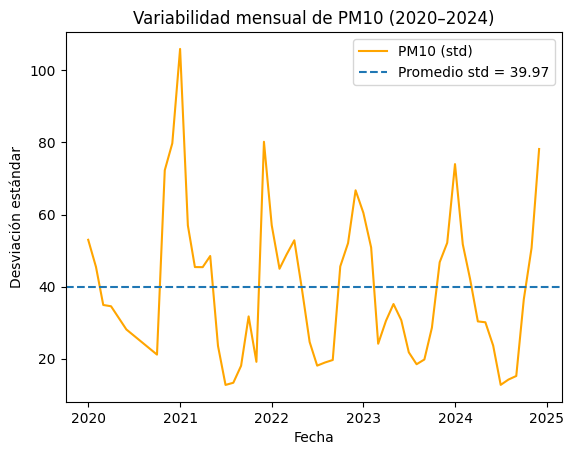

In [15]:
prom_pm10 = df_mes_std["PM10"].mean()

plt.figure()
plt.plot(df_mes_std["fecha"], df_mes_std["PM10"], label="PM10 (std)", color="orange")
plt.axhline(prom_pm10, linestyle="--", label=f"Promedio std = {prom_pm10:.2f}")

plt.xlabel("Fecha")
plt.ylabel("Desviación estándar")
plt.title("Variabilidad mensual de PM10 (2020–2024)")
plt.legend()
plt.show()

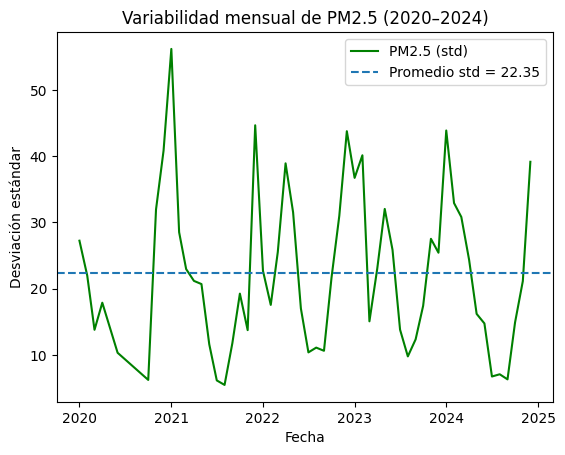

In [16]:
prom_pm25 = df_mes_std["PM2.5"].mean()

plt.figure()
plt.plot(df_mes_std["fecha"], df_mes_std["PM2.5"], label="PM2.5 (std)", color="green")
plt.axhline(prom_pm25, linestyle="--", label=f"Promedio std = {prom_pm25:.2f}")

plt.xlabel("Fecha")
plt.ylabel("Desviación estándar")
plt.title("Variabilidad mensual de PM2.5 (2020–2024)")
plt.legend()
plt.show()

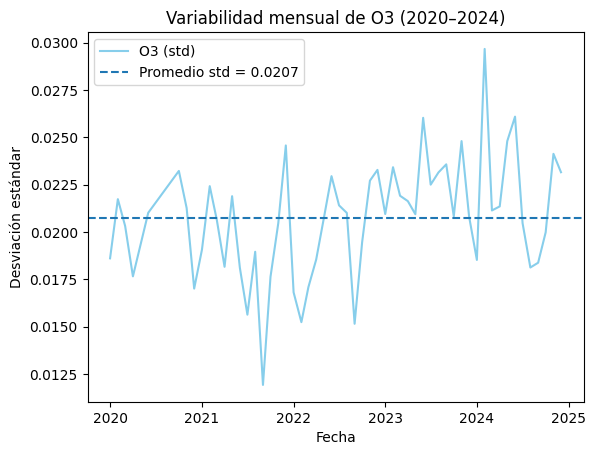

In [17]:
prom_o3 = df_mes_std["O3"].mean()

plt.figure()
plt.plot(df_mes_std["fecha"], df_mes_std["O3"], label="O3 (std)", color="skyblue")
plt.axhline(prom_o3, linestyle="--", label=f"Promedio std = {prom_o3:.4f}")

plt.xlabel("Fecha")
plt.ylabel("Desviación estándar")
plt.title("Variabilidad mensual de O3 (2020–2024)")
plt.legend()
plt.show()

## **2. ¿Qué año tuvo peor calidad del aire?**

Para responder esta pregunta, se buscó comparar la calidad del aire entre los años 2020 y 2024 utilizando los contaminantes disponibles en el dataset: **O3, PM10 y PM2.5**.

>Antes de calcular el promedio anual de cada contaminante se normalizaron los datos contaminantes a la misma escala donde se genero un nuevo indice de contaminacion evitando el sesgo de los resultados


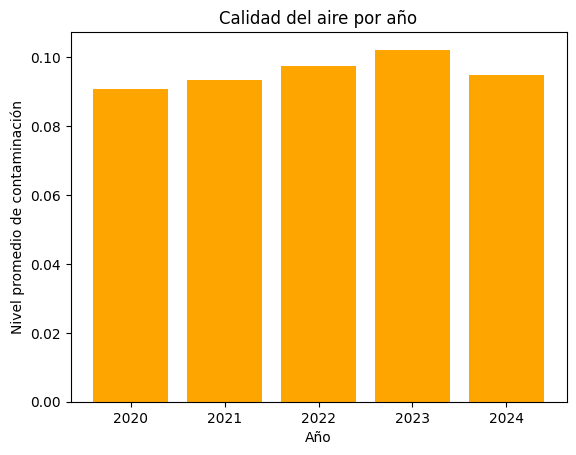

In [6]:
df_norm = df.copy()

for col in ["O3", "PM10", "PM2.5"]:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df_anual = df_norm.groupby("anio")[["O3", "PM10", "PM2.5"]].mean()
df_anual["indice"] = df_anual.mean(axis=1)
df_anual = df_anual.reset_index()

plt.figure()
plt.bar(df_anual["anio"], df_anual["indice"],color="orange")
plt.xlabel("Año")
plt.ylabel("Nivel promedio de contaminación")
plt.title("Calidad del aire por año")
plt.show()

### Resultado

Después del ajuste, se identificó que:

> **El año 2023 presenta la peor calidad del aire en términos relativos**, considerando el comportamiento equilibrado de todos los contaminantes.


### Interpretación

Esto indica que:

- Aunque otros años (como 2022) presentaban valores altos en términos absolutos,
- El año 2023 muestra un comportamiento más crítico cuando todos los contaminantes se consideran de manera equitativa.


## 3. ¿Cuál es la estación que muestra mayores patrones de riesgo ambiental y sus niveles de contaminantes (último mes de 2024)?

Para responder esta pregunta, se buscó identificar la estación con mayor riesgo ambiental considerando tanto los niveles de contaminación como su variabilidad en el tiempo.


### Selección del periodo de análisis

Se filtraron los datos correspondientes al año 2024 y posteriormente se seleccionó el **último mes disponible** dentro de este año. Esto permite enfocar el análisis en el periodo más reciente del dataset.



### Definición del índice de riesgo

Para cuantificar el riesgo ambiental, se construyó un índice combinando:

- El promedio de los contaminantes (nivel general de contaminación)
- La desviación estándar (variabilidad o inestabilidad)

El índice se definió como:

\[
\text{Índice de riesgo} = \text{promedio de medias} + \text{promedio de desviaciones estándar}
\]

Este enfoque permite identificar estaciones que no solo presentan altos niveles de contaminación, sino también fluctuaciones importantes que pueden representar mayor riesgo para la salud.







In [ ]:

df["datetime"] = pd.to_datetime(df["datetime"])

# Filtrar 2024
df_2024 = df[df["anio"] == 2024]

# Obtener último mes disponible
ultimo_mes = df_2024["datetime"].dt.month.max()
df_ultimo_mes = df_2024[df_2024["datetime"].dt.month == ultimo_mes]


df_riesgo = df_ultimo_mes.groupby("estacion")[["O3", "PM10", "PM2.5"]].agg(["mean", "std"])
df_riesgo.columns = ["_".join(col) for col in df_riesgo.columns]

# indice de riesgo
df_riesgo["indice_riesgo"] = (
    df_riesgo[["O3_mean", "PM10_mean", "PM2.5_mean"]].mean(axis=1) +
    df_riesgo[["O3_std", "PM10_std", "PM2.5_std"]].mean(axis=1)
)


df_riesgo_sorted = df_riesgo.sort_values("indice_riesgo", ascending=False)

# Estacion con peor calidad
print(df_riesgo_sorted.head(1))

             O3_mean    O3_std   PM10_mean    PM10_std  PM2.5_mean  PM2.5_std  \
estacion                                                                        
Las Pintas  0.020155  0.025134  160.723521  118.981591   62.953232  62.236003   

            indice_riesgo  
estacion                   
Las Pintas     134.979879  


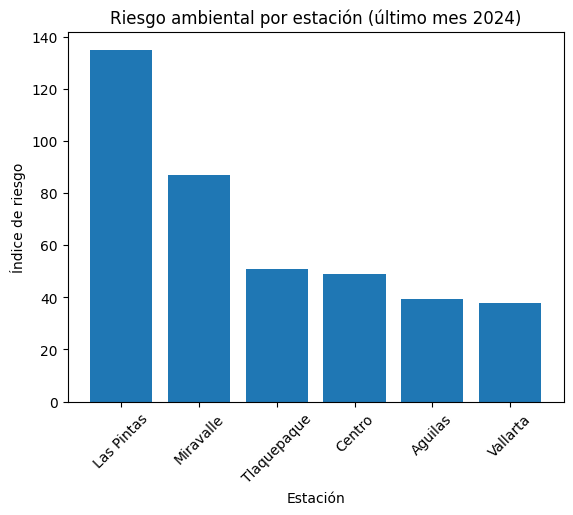

In [18]:
plt.figure()
plt.bar(df_riesgo_sorted.index, df_riesgo_sorted["indice_riesgo"])
plt.xticks(rotation=45)
plt.xlabel("Estación")
plt.ylabel("Índice de riesgo")
plt.title("Riesgo ambiental por estación (último mes 2024)")
plt.show()